BIBLIOTECAS CARREGADAS COM SUCESSO
matplotlib: Biblioteca para visualização de dados
sklearn: Biblioteca de Machine Learning
numpy: Biblioteca para computação numérica


INFORMAÇÕES SOBRE OS DADOS
Total de regiões com infrações: 12
Total de infrações: 12 milhões
Cada ponto representa: 1 milhão de infrações

AMOSTRA DOS DADOS (primeiras 5 regiões):
--------------------------------------------------------------------------------
Região | Coordenada X | Coordenada Y | Infrações
--------------------------------------------------------------------------------
   1   |      90.0    |     225.0    | 1 milhão
   2   |      90.0    |     325.0    | 1 milhão
   3   |      75.0    |      90.0    | 1 milhão
   4   |     125.0    |     140.0    | 1 milhão
   5   |     125.0    |      90.0    | 1 milhão
--------------------------------------------------------------------------------


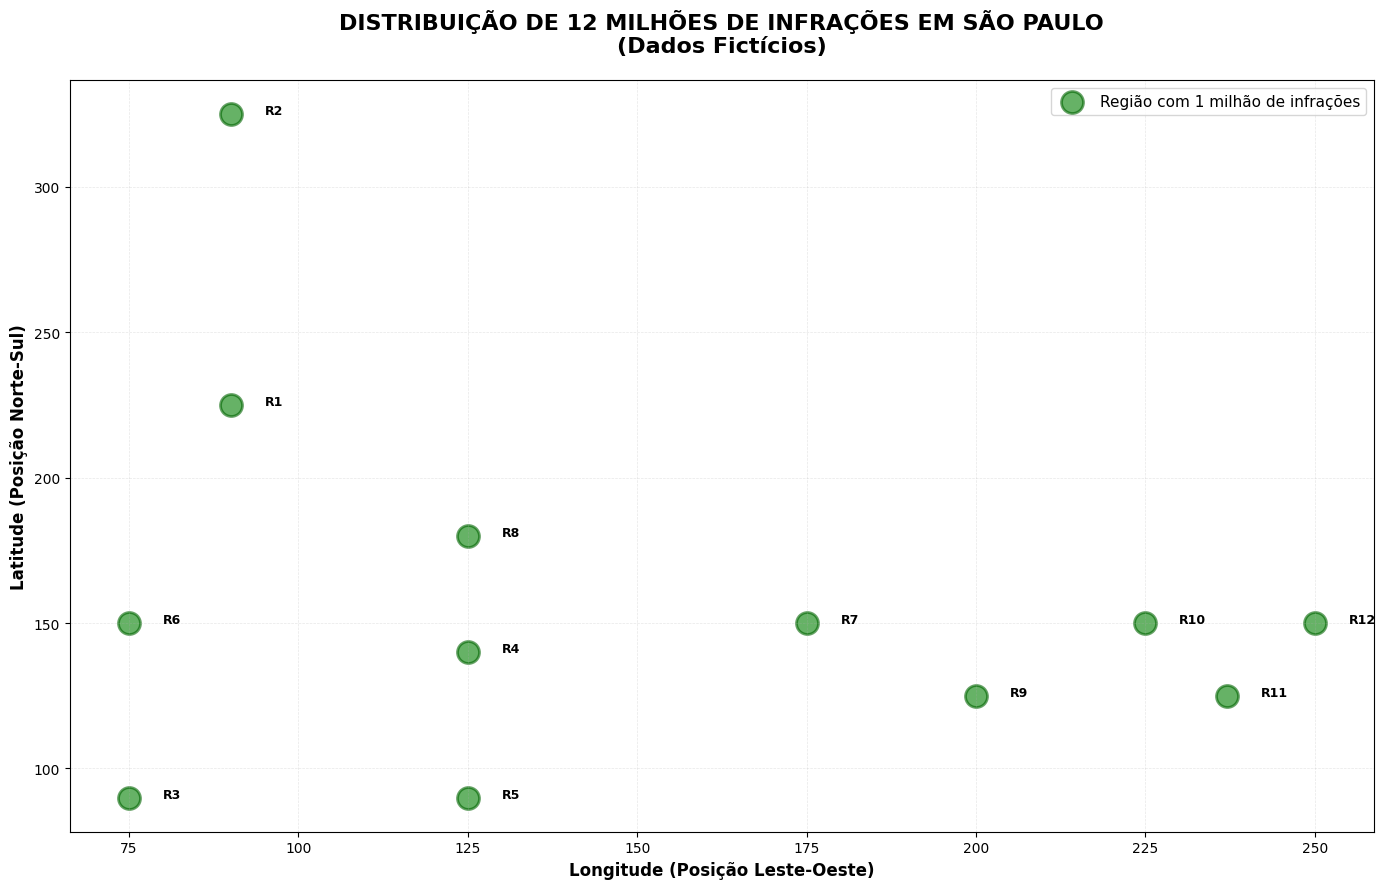



GRÁFICO PLOTADO: Distribuição das Infrações
ANÁLISE VISUAL:
- Cada ponto verde representa 1 milhão de infrações
- Observe como os pontos estão distribuídos no espaço
- Tente imaginar onde VOCÊ colocaria o radar olhando apenas o gráfico


PREPARAÇÃO DOS DADOS
Tipo original dos dados: <class 'list'>
Tipo após conversão: <class 'numpy.ndarray'>
Formato do array (linhas, colunas): (12, 2)
  - 12 regiões (linhas)
  - 2 coordenadas por região (colunas: X e Y)

Array NumPy criado:
[[ 90 225]
 [ 90 325]
 [ 75  90]
 [125 140]
 [125  90]
 [ 75 150]
 [175 150]
 [125 180]
 [200 125]
 [225 150]
 [237 125]
 [250 150]]


INICIANDO TREINAMENTO DO MODELO K-MEANS
Configuração:
  - Número de clusters (radares): 1
  - Random state: 0 (para reprodutibilidade)

Processando...
--------------------------------------------------------------------------------
TREINAMENTO CONCLUÍDO COM SUCESSO


RESULTADOS DO K-MEANS

1. RÓTULOS DOS CLUSTERS (LABELS):
-----------------------------------------------------------

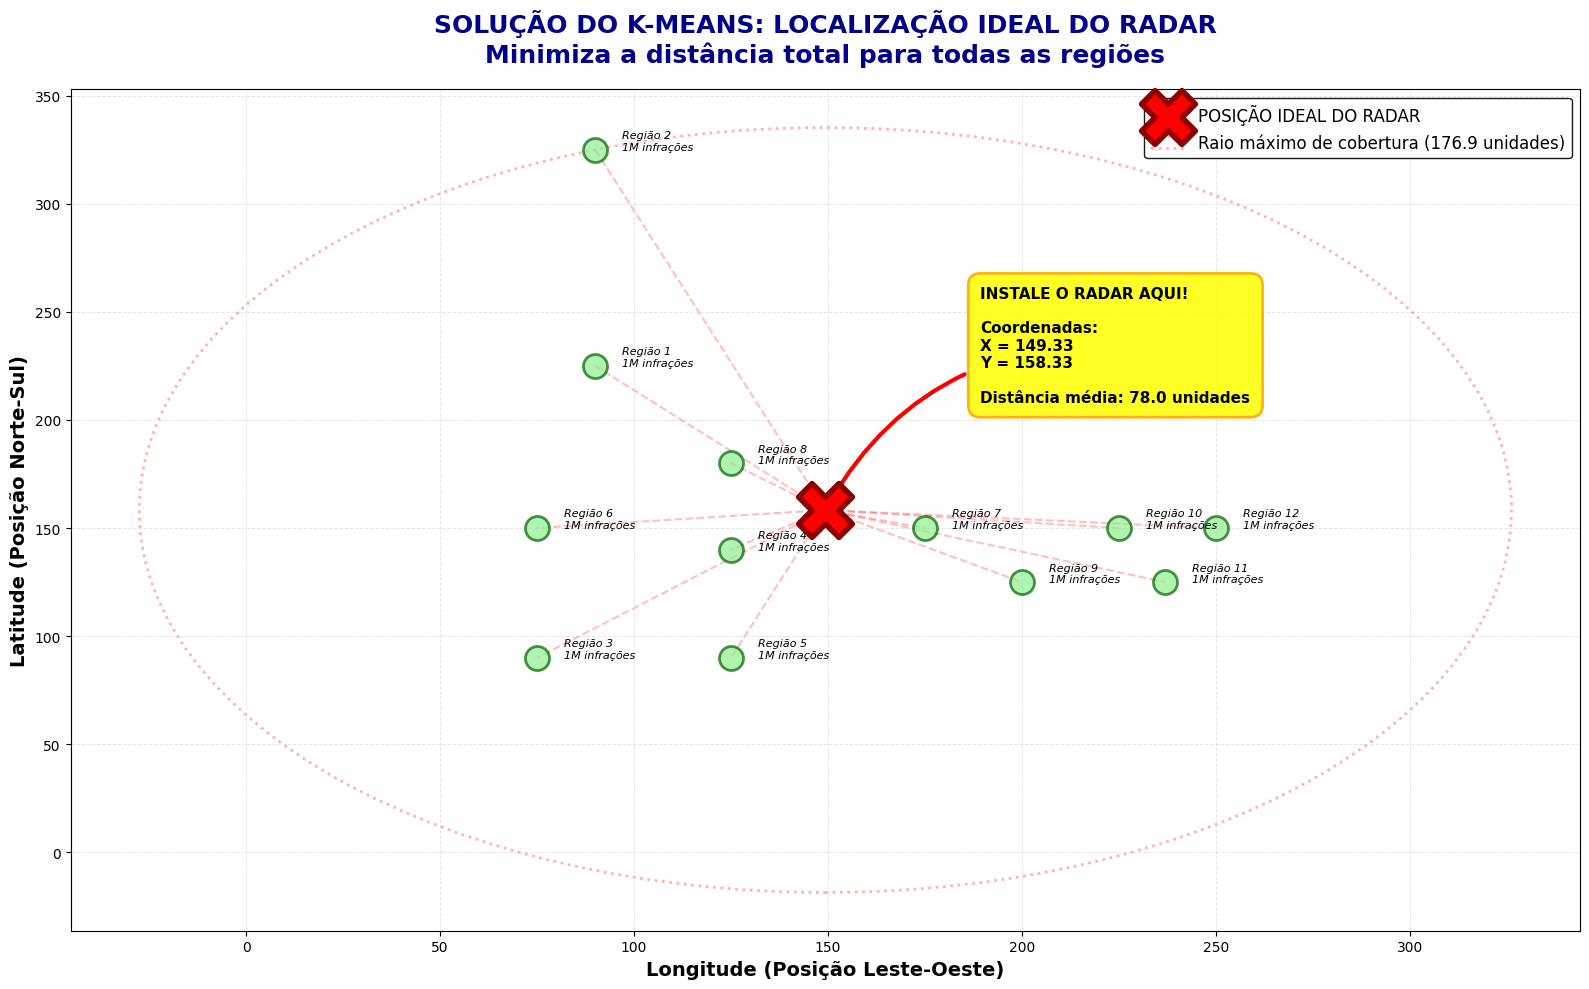



VISUALIZAÇÃO COMPLETA DA SOLUÇÃO
Elementos do gráfico:
  - Pontos verdes: Regiões com 1 milhão de infrações cada
  - X vermelho grande: Posição ideal do radar
  - Linhas tracejadas: Conexões entre radar e regiões
  - Círculo pontilhado: Raio máximo de cobertura do radar


TESTANDO PREVISÕES DO MODELO

NOVA INFRAÇÃO DETECTADA:
  Coordenada X: 40
  Coordenada Y: 120
--------------------------------------------------------------------------------

RESULTADO DA PREVISÃO:
  Cluster (Radar) responsável: 0
  Interpretação: O Radar 0 (único radar) deve atender

  Distância até o radar: 115.86 unidades

COMPARAÇÃO:
  Esta distância (115.86) vs média das outras (78.01)
  A nova infração está MAIS DISTANTE que a média


EXPERIMENTO 1: E SE TIVÉSSEMOS ORÇAMENTO PARA 2 RADARES?

Configuração: 2 radares (K=2)
Processando...
--------------------------------------------------------------------------------

RESULTADOS COM 2 RADARES:

Posição dos radares:
  Radar 1:
    - Coordenada X: 174.00
    - Co

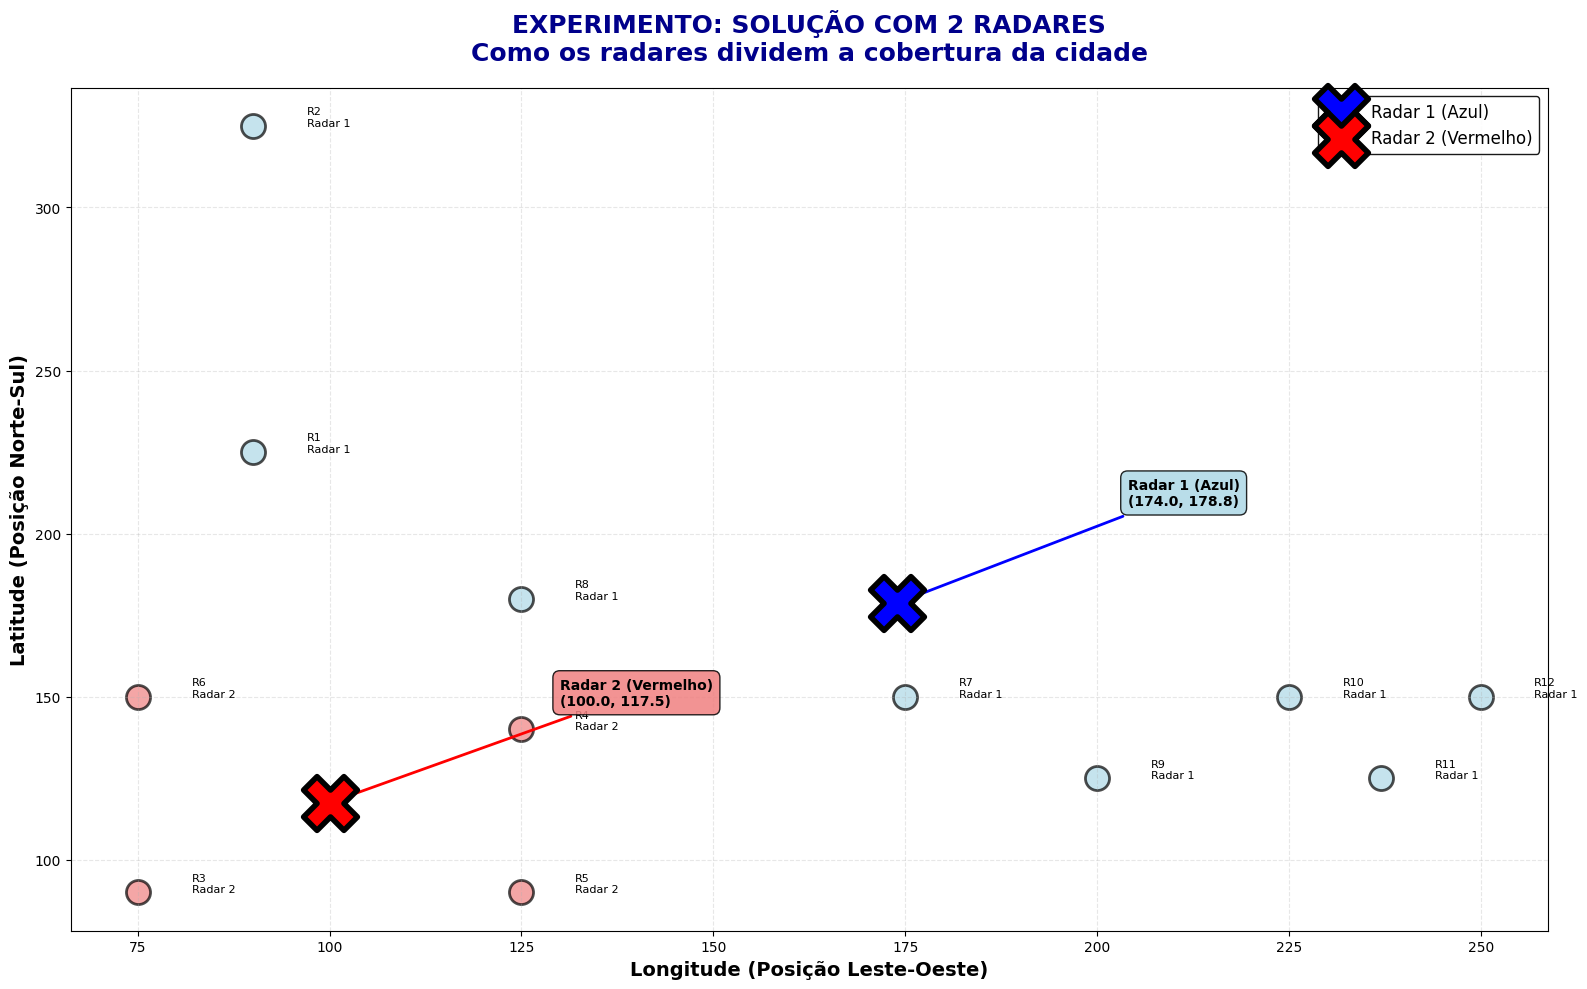



EXPERIMENTO 2: MÉTODO DO COTOVELO
Quantos radares são realmente necessários?

Testando diferentes números de radares...
--------------------------------------------------------------------------------
 K (Radares) |    Inércia    | Melhoria vs K-1
--------------------------------------------------------------------------------
      1       |    91505.33  |       -
      2       |    66898.50  |    26.9%
      3       |    18555.20  |    72.3%
      4       |    13583.00  |    26.8%
      5       |     8891.83  |    34.5%
      6       |     5137.67  |    42.2%
--------------------------------------------------------------------------------


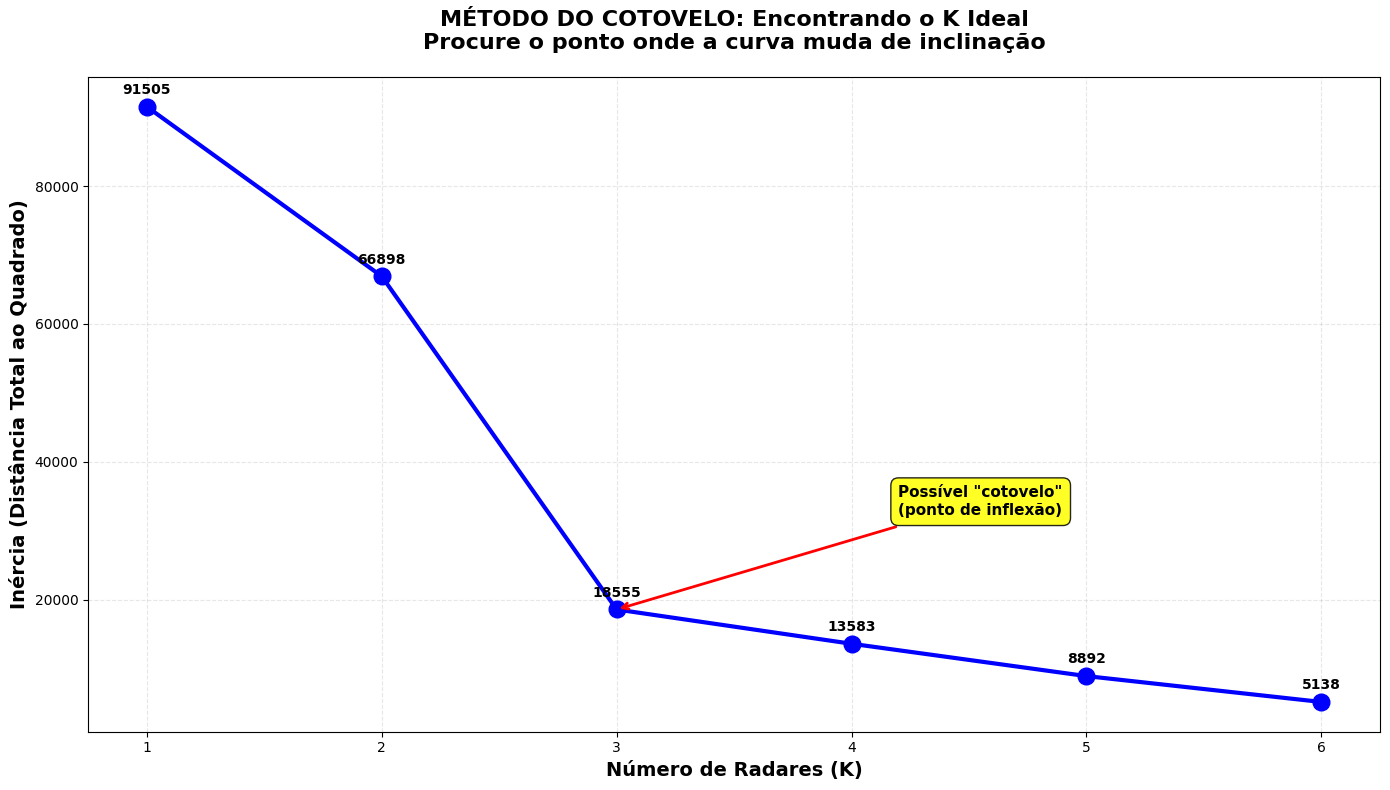



INTERPRETAÇÃO DO MÉTODO DO COTOVELO

O que observar no gráfico:
  1. A inércia sempre DIMINUI quando aumentamos K
  2. Procure onde a curva 'dobra' ou muda de inclinação
  3. Este ponto é o 'cotovelo' - o K ideal

Por que isso funciona?
  - Adicionar radares sempre melhora a cobertura
  - Mas depois de certo ponto, a melhoria é pequena
  - O cotovelo indica o ponto de retorno decrescente

Neste exemplo:
  - De K=1 para K=2: Melhoria significativa
  - De K=2 para K=3: Ainda há melhoria razoável
  - Acima de K=3: Melhorias marginais

Recomendação: K entre 2 e 3 radares parece ideal


TABELA COMPARATIVA: TODAS AS SOLUÇÕES TESTADAS


--------------------------------------------------------------------------------
 K | Inércia  | Melhoria | Distância | Recomendação
   |          |   (%)    | Média     |
--------------------------------------------------------------------------------
 1 |    91505 |    -     |    78.0   | Bom custo-benefício
 2 |    66898 |   26.9% |    64.5   | Bom custo-

In [3]:
"""
================================================================================
NOTEBOOK DIDÁTICO: APRENDIZADO NÃO SUPERVISIONADO COM K-MEANS
================================================================================

Curso: Inteligência Artificial Aplicada - FAETEC Resende
Professor: Bruno Menezes
Carga Horária: 240h/a

OBJETIVOS DESTA AULA:
- Entender o que é Aprendizado Não Supervisionado
- Conhecer o algoritmo K-Means e suas aplicações
- Resolver um problema real usando Python
- Interpretar resultados visuais de clustering
- Aplicar IA para tomada de decisões

PROBLEMA A SER RESOLVIDO:
A Secretaria de Trânsito de São Paulo precisa instalar radares de detecção
de velocidade. Com orçamento limitado para apenas 1 radar, onde deve ser
instalado para atender o maior número possível de infrações?

Dados: 12 milhões de infrações distribuídas pelo município
Cada ponto no gráfico representa 1 milhão de infrações
================================================================================
"""

# ================================================================================
# PARTE 1: CONCEITOS FUNDAMENTAIS
# ================================================================================

"""
O QUE É MACHINE LEARNING (APRENDIZADO DE MÁQUINA)?

Machine Learning é um subcampo da Inteligência Artificial onde computadores
aprendem padrões a partir de dados, sem serem explicitamente programados
para cada tarefa.

TIPOS DE APRENDIZADO DE MÁQUINA:

1. APRENDIZADO SUPERVISIONADO:
   - O computador aprende com exemplos rotulados
   - Exemplo: Mostrar fotos de gatos e cachorros já identificadas
   - Aplicações: Classificação de emails (spam/não-spam), reconhecimento facial

2. APRENDIZADO NÃO SUPERVISIONADO (nosso foco hoje):
   - O computador descobre padrões sozinho, sem rótulos
   - Exemplo: Agrupar clientes com comportamentos similares
   - Aplicações: Segmentação de mercado, detecção de anomalias

3. APRENDIZADO POR REFORÇO:
   - O computador aprende por tentativa e erro
   - Exemplo: Aprender a jogar xadrez
   - Aplicações: Robótica, jogos, veículos autônomos

================================================================================
O ALGORITMO K-MEANS
================================================================================

K-Means é um algoritmo de CLUSTERING (agrupamento) que divide dados em
K grupos baseado na similaridade entre os pontos.

COMO FUNCIONA (passo a passo):

Passo 1: Escolher K (número de grupos desejados)
Passo 2: Inicializar K centros (centróides) aleatoriamente
Passo 3: Atribuir cada ponto ao centro mais próximo
Passo 4: Recalcular os centros baseado nos pontos de cada grupo
Passo 5: Repetir passos 3 e 4 até convergência

CONCEITOS-CHAVE:

- K: Número de clusters (grupos) que queremos criar
- CENTRÓIDE: O centro geométrico de um cluster (como uma "média" dos pontos)
- CLUSTER: Grupo de pontos similares/próximos
- INÉRCIA: Soma das distâncias dos pontos aos seus centróides (menor é melhor)
- LABEL: Rótulo numérico do cluster (0, 1, 2, ...)

APLICAÇÕES REAIS:

- Marketing: Segmentar clientes por comportamento de compra
- Saúde: Agrupar pacientes com sintomas similares
- Urbanismo: Planejar localização de serviços públicos
- Logística: Otimizar rotas e centros de distribuição
- Telecomunicações: Posicionar antenas de celular
"""

# ================================================================================
# PARTE 2: IMPORTAÇÃO DE BIBLIOTECAS
# ================================================================================

"""
Bibliotecas são conjuntos de código já prontos que facilitam nosso trabalho.
Não precisamos criar tudo do zero!

BIBLIOTECAS QUE VAMOS USAR:

- matplotlib: Para criar gráficos e visualizações
- sklearn (scikit-learn): Contém algoritmos de Machine Learning, incluindo K-Means
- numpy: Para operações matemáticas e trabalhar com arrays
"""

# Importar bibliotecas necessárias
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
import warnings

# Configurações para melhorar a visualização
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')  # Ocultar avisos desnecessários

print("="*80)
print("BIBLIOTECAS CARREGADAS COM SUCESSO")
print("="*80)
print("matplotlib: Biblioteca para visualização de dados")
print("sklearn: Biblioteca de Machine Learning")
print("numpy: Biblioteca para computação numérica")
print("="*80)

# ================================================================================
# PARTE 3: DEFINIÇÃO DOS DADOS DO PROBLEMA
# ================================================================================

"""
CONTEXTO DO PROBLEMA:

A cidade de São Paulo registrou 12 milhões de infrações de trânsito
distribuídas em diferentes regiões. Cada ponto abaixo representa
1 milhão de infrações em uma determinada localização.

Os valores [X, Y] são coordenadas fictícias que representam:
- X: Posição Leste-Oeste (Longitude)
- Y: Posição Norte-Sul (Latitude)

TAREFA:
Com orçamento para instalar apenas 1 radar, precisamos encontrar
a localização ideal que minimize a distância total para todas as
regiões de infrações.
"""

# Dados das infrações
# Cada linha representa 1 milhão de infrações
# Formato: [coordenada X, coordenada Y]
population = [
    [90, 225],   # Região 1: 1 milhão de infrações
    [90, 325],   # Região 2: 1 milhão de infrações
    [75, 90],    # Região 3: 1 milhão de infrações
    [125, 140],  # Região 4: 1 milhão de infrações
    [125, 90],   # Região 5: 1 milhão de infrações
    [75, 150],   # Região 6: 1 milhão de infrações
    [175, 150],  # Região 7: 1 milhão de infrações
    [125, 180],  # Região 8: 1 milhão de infrações
    [200, 125],  # Região 9: 1 milhão de infrações
    [225, 150],  # Região 10: 1 milhão de infrações
    [237, 125],  # Região 11: 1 milhão de infrações
    [250, 150],  # Região 12: 1 milhão de infrações
]

# Exibir informações sobre os dados
print("\n")
print("="*80)
print("INFORMAÇÕES SOBRE OS DADOS")
print("="*80)
print(f"Total de regiões com infrações: {len(population)}")
print(f"Total de infrações: {len(population)} milhões")
print(f"Cada ponto representa: 1 milhão de infrações")
print("="*80)

# Mostrar as primeiras 5 regiões como exemplo
print("\nAMOSTRA DOS DADOS (primeiras 5 regiões):")
print("-"*80)
print("Região | Coordenada X | Coordenada Y | Infrações")
print("-"*80)
for i in range(min(5, len(population))):
    print(f"  {i+1:2d}   |    {population[i][0]:6.1f}    |    {population[i][1]:6.1f}    | 1 milhão")
print("-"*80)

# ================================================================================
# PARTE 4: VISUALIZAÇÃO INICIAL DOS DADOS
# ================================================================================

"""
IMPORTÂNCIA DA VISUALIZAÇÃO:

Antes de aplicar qualquer algoritmo, é fundamental visualizar os dados.
Isso nos ajuda a:
- Entender a distribuição espacial das infrações
- Identificar possíveis padrões visuais
- Ter uma intuição inicial sobre onde o radar deveria ficar
- Validar se os dados fazem sentido
"""

# Criar figura para visualização
plt.figure(figsize=(14, 9))

# Configurar título e labels
plt.title('DISTRIBUIÇÃO DE 12 MILHÕES DE INFRAÇÕES EM SÃO PAULO\n(Dados Fictícios)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Longitude (Posição Leste-Oeste)', fontsize=12, fontweight='bold')
plt.ylabel('Latitude (Posição Norte-Sul)', fontsize=12, fontweight='bold')

# Plotar cada região de infrações
for i in range(len(population)):
    plt.scatter(
        population[i][0],      # Coordenada X
        population[i][1],      # Coordenada Y
        color='green',         # Cor dos pontos
        s=250,                 # Tamanho dos pontos
        alpha=0.6,             # Transparência
        edgecolors='darkgreen',# Cor da borda
        linewidth=2            # Espessura da borda
    )
    # Adicionar número da região ao lado do ponto
    plt.text(population[i][0] + 5, population[i][1],
             f'R{i+1}', fontsize=9, fontweight='bold')

# Adicionar grade para facilitar leitura
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Adicionar legenda
plt.scatter([], [], color='green', s=250, alpha=0.6,
           edgecolors='darkgreen', linewidth=2,
           label='Região com 1 milhão de infrações')
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

print("\n")
print("="*80)
print("GRÁFICO PLOTADO: Distribuição das Infrações")
print("="*80)
print("ANÁLISE VISUAL:")
print("- Cada ponto verde representa 1 milhão de infrações")
print("- Observe como os pontos estão distribuídos no espaço")
print("- Tente imaginar onde VOCÊ colocaria o radar olhando apenas o gráfico")
print("="*80)

# ================================================================================
# PARTE 5: PREPARAÇÃO DOS DADOS PARA O K-MEANS
# ================================================================================

"""
PREPARAÇÃO DOS DADOS:

O algoritmo K-Means do scikit-learn espera receber os dados em formato
de array NumPy. NumPy é uma biblioteca Python otimizada para operações
matemáticas com arrays multidimensionais.

Vamos converter nossa lista Python em um array NumPy.
"""

# Converter lista para array NumPy
X = np.array(population)

print("\n")
print("="*80)
print("PREPARAÇÃO DOS DADOS")
print("="*80)
print(f"Tipo original dos dados: {type(population)}")
print(f"Tipo após conversão: {type(X)}")
print(f"Formato do array (linhas, colunas): {X.shape}")
print(f"  - {X.shape[0]} regiões (linhas)")
print(f"  - {X.shape[1]} coordenadas por região (colunas: X e Y)")
print("="*80)

# Mostrar como ficou o array
print("\nArray NumPy criado:")
print(X)

# ================================================================================
# PARTE 6: APLICAÇÃO DO ALGORITMO K-MEANS
# ================================================================================

"""
TREINAMENTO DO MODELO K-MEANS:

Agora vamos aplicar o algoritmo K-Means aos nossos dados.

PARÂMETROS IMPORTANTES:

- n_clusters=1: Queremos encontrar 1 posição ideal (temos orçamento para 1 radar)
- random_state=0: Garante reprodutibilidade (sempre teremos os mesmos resultados)

O QUE O ALGORITMO FAZ:

1. Como temos apenas 1 cluster, o algoritmo calculará o centróide
2. O centróide será a posição que minimiza a distância total para todas as regiões
3. Matematicamente, é como calcular a "média" das posições
"""

print("\n")
print("="*80)
print("INICIANDO TREINAMENTO DO MODELO K-MEANS")
print("="*80)
print("Configuração:")
print("  - Número de clusters (radares): 1")
print("  - Random state: 0 (para reprodutibilidade)")
print("\nProcessando...")
print("-"*80)

# Criar o modelo K-Means
kmeans = KMeans(n_clusters=1, random_state=0)

# Treinar o modelo com nossos dados
kmeans.fit(X)

print("TREINAMENTO CONCLUÍDO COM SUCESSO")
print("="*80)

# ================================================================================
# PARTE 7: ANÁLISE DOS RESULTADOS
# ================================================================================

"""
INTERPRETAÇÃO DOS RESULTADOS:

Após o treinamento, o modelo K-Means nos fornece várias informações:

1. LABELS: A qual cluster cada região pertence (sempre 0 neste caso, pois temos só 1 cluster)
2. CLUSTER_CENTERS: As coordenadas do centróide (posição ideal do radar)
3. INERTIA: Soma das distâncias ao quadrado de cada ponto ao seu centróide
   (quanto menor, melhor a qualidade do agrupamento)
"""

# Extrair resultados
labels = kmeans.labels_
centro = kmeans.cluster_centers_[0]
inercia = kmeans.inertia_

print("\n")
print("="*80)
print("RESULTADOS DO K-MEANS")
print("="*80)

# 1. Labels (rótulos dos clusters)
print("\n1. RÓTULOS DOS CLUSTERS (LABELS):")
print("-"*80)
print(f"Labels: {labels}")
print("\nInterpretação:")
print("  - Todos os pontos têm label [0]")
print("  - Isso significa que todos pertencem ao mesmo cluster")
print("  - Faz sentido porque temos apenas 1 radar (1 cluster)")

# 2. Posição do centróide
print("\n2. POSIÇÃO IDEAL DO RADAR (CENTRÓIDE):")
print("-"*80)
print(f"Coordenada X (Leste-Oeste): {centro[0]:.2f}")
print(f"Coordenada Y (Norte-Sul): {centro[1]:.2f}")
print("\nInterpretação:")
print("  - Esta é a posição que minimiza a distância total")
print("  - O radar nesta posição atenderá todas as 12 regiões")
print("  - É como o 'centro de gravidade' das infrações")

# 3. Inércia (qualidade do agrupamento)
print("\n3. QUALIDADE DA SOLUÇÃO (INÉRCIA):")
print("-"*80)
print(f"Inércia: {inercia:.2f}")
print("\nInterpretação:")
print("  - Inércia = soma das distâncias ao quadrado até o centróide")
print("  - Quanto MENOR a inércia, MELHOR a solução")
print("  - Representa o quão 'espalhadas' as regiões estão")

# Calcular estatísticas adicionais
distancias = []
for ponto in population:
    dist = np.sqrt((ponto[0] - centro[0])**2 + (ponto[1] - centro[1])**2)
    distancias.append(dist)

print("\n4. ESTATÍSTICAS DAS DISTÂNCIAS:")
print("-"*80)
print(f"Distância mínima até o radar: {min(distancias):.2f} unidades")
print(f"Distância máxima até o radar: {max(distancias):.2f} unidades")
print(f"Distância média até o radar: {np.mean(distancias):.2f} unidades")
print(f"Desvio padrão das distâncias: {np.std(distancias):.2f} unidades")

print("\n" + "="*80)

# ================================================================================
# PARTE 8: VISUALIZAÇÃO DA SOLUÇÃO
# ================================================================================

"""
VISUALIZAÇÃO FINAL:

Agora vamos criar um gráfico completo mostrando:
- As regiões de infrações (pontos verdes)
- A posição ideal do radar (X vermelho grande)
- Linhas conectando o radar a cada região
- Anotações explicativas
"""

# Criar figura
plt.figure(figsize=(16, 10))

# Título e labels
plt.title('SOLUÇÃO DO K-MEANS: LOCALIZAÇÃO IDEAL DO RADAR\n' +
          'Minimiza a distância total para todas as regiões',
          fontsize=18, fontweight='bold', pad=20, color='darkblue')
plt.xlabel('Longitude (Posição Leste-Oeste)', fontsize=14, fontweight='bold')
plt.ylabel('Latitude (Posição Norte-Sul)', fontsize=14, fontweight='bold')

# 1. Plotar as regiões de infrações
for i in range(len(population)):
    plt.scatter(
        population[i][0],
        population[i][1],
        color='lightgreen',
        s=300,
        alpha=0.7,
        edgecolors='darkgreen',
        linewidth=2,
        zorder=2  # Camada de renderização
    )
    # Adicionar número da região
    plt.text(
        population[i][0] + 7,
        population[i][1],
        f'Região {i+1}\n1M infrações',
        fontsize=8,
        style='italic',
        ha='left'
    )

# 2. Plotar linhas conectando o radar a cada região
for i in range(len(population)):
    plt.plot(
        [centro[0], population[i][0]],
        [centro[1], population[i][1]],
        'r--',           # Linha vermelha tracejada
        alpha=0.25,      # Bem transparente
        linewidth=1.5,
        zorder=1         # Atrás dos pontos
    )

# 3. Plotar o RADAR (ponto central)
plt.scatter(
    centro[0],
    centro[1],
    color='red',
    marker='X',         # Formato de X
    s=1500,             # Bem grande
    edgecolors='darkred',
    linewidth=4,
    label='POSIÇÃO IDEAL DO RADAR',
    zorder=5            # Por cima de tudo
)

# 4. Adicionar anotação detalhada
texto_anotacao = f'INSTALE O RADAR AQUI!\n\n' \
                 f'Coordenadas:\n' \
                 f'X = {centro[0]:.2f}\n' \
                 f'Y = {centro[1]:.2f}\n\n' \
                 f'Distância média: {np.mean(distancias):.1f} unidades'

plt.annotate(
    texto_anotacao,
    xy=(centro[0], centro[1]),
    xytext=(centro[0] + 40, centro[1] + 50),
    fontsize=11,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.8", facecolor="yellow", alpha=0.85, edgecolor='orange', linewidth=2),
    arrowprops=dict(arrowstyle='->', lw=3, color='red', connectionstyle='arc3,rad=0.3')
)

# 5. Adicionar círculo indicando área de cobertura
circulo = plt.Circle(
    (centro[0], centro[1]),
    max(distancias),
    color='red',
    fill=False,
    linestyle=':',
    linewidth=2,
    alpha=0.3,
    label=f'Raio máximo de cobertura ({max(distancias):.1f} unidades)'
)
plt.gca().add_patch(circulo)

# Configurações finais do gráfico
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
plt.legend(fontsize=12, loc='upper right', framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

print("\n")
print("="*80)
print("VISUALIZAÇÃO COMPLETA DA SOLUÇÃO")
print("="*80)
print("Elementos do gráfico:")
print("  - Pontos verdes: Regiões com 1 milhão de infrações cada")
print("  - X vermelho grande: Posição ideal do radar")
print("  - Linhas tracejadas: Conexões entre radar e regiões")
print("  - Círculo pontilhado: Raio máximo de cobertura do radar")
print("="*80)

# ================================================================================
# PARTE 9: FAZENDO PREVISÕES COM O MODELO TREINADO
# ================================================================================

"""
APLICAÇÃO PRÁTICA: PREVISÃO

Agora que temos o modelo treinado, podemos usá-lo para fazer previsões.

CENÁRIO:
Uma nova infração foi detectada nas coordenadas [40, 120].
Qual radar deve atender essa ocorrência?

Embora tenhamos apenas 1 radar neste exemplo, em cenários com múltiplos
radares, o modelo prevê qual radar está mais próximo da nova infração.
"""

print("\n")
print("="*80)
print("TESTANDO PREVISÕES DO MODELO")
print("="*80)

# Simular nova infração
nova_infracao = [[40, 120]]

print(f"\nNOVA INFRAÇÃO DETECTADA:")
print(f"  Coordenada X: {nova_infracao[0][0]}")
print(f"  Coordenada Y: {nova_infracao[0][1]}")
print("-"*80)

# Fazer previsão
cluster_responsavel = kmeans.predict(nova_infracao)

print(f"\nRESULTADO DA PREVISÃO:")
print(f"  Cluster (Radar) responsável: {cluster_responsavel[0]}")
print(f"  Interpretação: O Radar 0 (único radar) deve atender")

# Calcular distância da nova infração até o radar
dist_x = centro[0] - nova_infracao[0][0]
dist_y = centro[1] - nova_infracao[0][1]
distancia_nova = np.sqrt(dist_x**2 + dist_y**2)

print(f"\n  Distância até o radar: {distancia_nova:.2f} unidades")

# Comparar com as distâncias existentes
print(f"\nCOMPARAÇÃO:")
print(f"  Esta distância ({distancia_nova:.2f}) vs média das outras ({np.mean(distancias):.2f})")
if distancia_nova > np.mean(distancias):
    print(f"  A nova infração está MAIS DISTANTE que a média")
else:
    print(f"  A nova infração está MAIS PRÓXIMA que a média")

print("="*80)

# ================================================================================
# PARTE 10: EXPERIMENTO 1 - E SE TIVÉSSEMOS 2 RADARES?
# ================================================================================

"""
EXPERIMENTO AVANÇADO: VARIANDO O NÚMERO DE CLUSTERS

Vamos investigar o que acontece quando aumentamos o número de radares.
Este experimento demonstra como o K-Means adapta sua solução conforme K muda.

QUESTÃO: Com orçamento para 2 radares, onde eles deveriam ficar?
"""

print("\n")
print("="*80)
print("EXPERIMENTO 1: E SE TIVÉSSEMOS ORÇAMENTO PARA 2 RADARES?")
print("="*80)

# Treinar novo modelo com K=2
kmeans_2 = KMeans(n_clusters=2, random_state=0)
kmeans_2.fit(X)

print("\nConfiguração: 2 radares (K=2)")
print("Processando...")
print("-"*80)

# Resultados
print("\nRESULTADOS COM 2 RADARES:")
print("\nPosição dos radares:")
for i in range(2):
    print(f"  Radar {i+1}:")
    print(f"    - Coordenada X: {kmeans_2.cluster_centers_[i][0]:.2f}")
    print(f"    - Coordenada Y: {kmeans_2.cluster_centers_[i][1]:.2f}")

print(f"\nDistribuição das regiões:")
print(f"  Regiões atendidas pelo Radar 1: {sum(kmeans_2.labels_ == 0)}")
print(f"  Regiões atendidas pelo Radar 2: {sum(kmeans_2.labels_ == 1)}")

print(f"\nQualidade da solução:")
print(f"  Inércia (K=1): {inercia:.2f}")
print(f"  Inércia (K=2): {kmeans_2.inertia_:.2f}")
print(f"  Melhoria: {((inercia - kmeans_2.inertia_) / inercia * 100):.1f}%")

print("="*80)

# Visualização com 2 radares
plt.figure(figsize=(16, 10))
plt.title('EXPERIMENTO: SOLUÇÃO COM 2 RADARES\n' +
          'Como os radares dividem a cobertura da cidade',
          fontsize=18, fontweight='bold', pad=20, color='darkblue')
plt.xlabel('Longitude (Posição Leste-Oeste)', fontsize=14, fontweight='bold')
plt.ylabel('Latitude (Posição Norte-Sul)', fontsize=14, fontweight='bold')

# Cores para diferenciar os clusters
cores_clusters = ['lightblue', 'lightcoral']
cores_radares = ['blue', 'red']
nomes_radares = ['Radar 1 (Azul)', 'Radar 2 (Vermelho)']

# Plotar regiões coloridas por cluster
for i in range(len(population)):
    cluster = kmeans_2.labels_[i]
    plt.scatter(
        population[i][0],
        population[i][1],
        color=cores_clusters[cluster],
        s=300,
        alpha=0.7,
        edgecolors='black',
        linewidth=2
    )
    plt.text(
        population[i][0] + 7,
        population[i][1],
        f'R{i+1}\nRadar {cluster+1}',
        fontsize=8,
        ha='left'
    )

# Plotar os 2 radares
for i in range(2):
    plt.scatter(
        kmeans_2.cluster_centers_[i][0],
        kmeans_2.cluster_centers_[i][1],
        color=cores_radares[i],
        marker='X',
        s=1500,
        edgecolors='black',
        linewidth=4,
        label=nomes_radares[i],
        zorder=5
    )

    # Anotações para cada radar
    plt.annotate(
        f'{nomes_radares[i]}\n({kmeans_2.cluster_centers_[i][0]:.1f}, {kmeans_2.cluster_centers_[i][1]:.1f})',
        xy=(kmeans_2.cluster_centers_[i][0], kmeans_2.cluster_centers_[i][1]),
        xytext=(kmeans_2.cluster_centers_[i][0] + 30, kmeans_2.cluster_centers_[i][1] + 30),
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", facecolor=cores_clusters[i], alpha=0.85, edgecolor='black'),
        arrowprops=dict(arrowstyle='->', lw=2, color=cores_radares[i])
    )

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='upper right', framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

# ================================================================================
# PARTE 11: EXPERIMENTO 2 - MÉTODO DO COTOVELO
# ================================================================================

"""
EXPERIMENTO: QUAL É O NÚMERO IDEAL DE RADARES?

O Método do Cotovelo (Elbow Method) nos ajuda a determinar o K ideal.

COMO FUNCIONA:
1. Testamos diferentes valores de K (1, 2, 3, 4, 5, 6...)
2. Para cada K, calculamos a inércia
3. Plotamos K vs Inércia
4. Procuramos um "cotovelo" no gráfico
5. O cotovelo indica onde adicionar mais radares não melhora muito

INTERPRETAÇÃO:
- Inércia sempre diminui quando aumentamos K
- Mas a partir de certo ponto, a melhoria é marginal
- O "cotovelo" é onde a curva muda de inclinação
"""

print("\n")
print("="*80)
print("EXPERIMENTO 2: MÉTODO DO COTOVELO")
print("Quantos radares são realmente necessários?")
print("="*80)

# Testar diferentes valores de K
k_valores = range(1, 7)
inercias = []
modelos = []

print("\nTestando diferentes números de radares...")
print("-"*80)
print(" K (Radares) |    Inércia    | Melhoria vs K-1")
print("-"*80)

for k in k_valores:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X)
    inercias.append(km.inertia_)
    modelos.append(km)

    if k == 1:
        print(f"      {k}       |  {km.inertia_:10.2f}  |       -")
    else:
        melhoria = ((inercias[-2] - inercias[-1]) / inercias[-2]) * 100
        print(f"      {k}       |  {km.inertia_:10.2f}  |   {melhoria:5.1f}%")

print("-"*80)

# Plotar gráfico do cotovelo
plt.figure(figsize=(14, 8))
plt.plot(k_valores, inercias, 'bo-', linewidth=3, markersize=12)

# Destacar cada ponto
for i, (k, inercia) in enumerate(zip(k_valores, inercias)):
    plt.text(k, inercia + max(inercias)*0.02, f'{inercia:.0f}',
             ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Número de Radares (K)', fontsize=14, fontweight='bold')
plt.ylabel('Inércia (Distância Total ao Quadrado)', fontsize=14, fontweight='bold')
plt.title('MÉTODO DO COTOVELO: Encontrando o K Ideal\n' +
          'Procure o ponto onde a curva muda de inclinação',
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(k_valores)

# Adicionar anotação explicativa
plt.annotate(
    'Possível "cotovelo"\n(ponto de inflexão)',
    xy=(3, inercias[2]),
    xytext=(4.2, inercias[2] + max(inercias)*0.15),
    fontsize=11,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.85),
    arrowprops=dict(arrowstyle='->', lw=2, color='red')
)

plt.tight_layout()
plt.show()

print("\n")
print("="*80)
print("INTERPRETAÇÃO DO MÉTODO DO COTOVELO")
print("="*80)
print("\nO que observar no gráfico:")
print("  1. A inércia sempre DIMINUI quando aumentamos K")
print("  2. Procure onde a curva 'dobra' ou muda de inclinação")
print("  3. Este ponto é o 'cotovelo' - o K ideal")
print("\nPor que isso funciona?")
print("  - Adicionar radares sempre melhora a cobertura")
print("  - Mas depois de certo ponto, a melhoria é pequena")
print("  - O cotovelo indica o ponto de retorno decrescente")
print("\nNeste exemplo:")
print("  - De K=1 para K=2: Melhoria significativa")
print("  - De K=2 para K=3: Ainda há melhoria razoável")
print("  - Acima de K=3: Melhorias marginais")
print("\nRecomendação: K entre 2 e 3 radares parece ideal")
print("="*80)

# ================================================================================
# PARTE 12: TABELA COMPARATIVA DE SOLUÇÕES
# ================================================================================

"""
RESUMO COMPARATIVO:

Vamos criar uma tabela comparando todas as soluções testadas.
"""

print("\n")
print("="*80)
print("TABELA COMPARATIVA: TODAS AS SOLUÇÕES TESTADAS")
print("="*80)
print("\n")
print("-"*80)
print(" K | Inércia  | Melhoria | Distância | Recomendação")
print("   |          |   (%)    | Média     |")
print("-"*80)

for i, k in enumerate(k_valores):
    if i == 0:
        melhoria_txt = "   -    "
    else:
        melhoria = ((inercias[i-1] - inercias[i]) / inercias[i-1]) * 100
        melhoria_txt = f"{melhoria:6.1f}%"

    # Calcular distância média para este K
    labels_temp = modelos[i].labels_
    centros_temp = modelos[i].cluster_centers_
    dist_media_temp = 0
    for j, ponto in enumerate(population):
        cluster_ponto = labels_temp[j]
        centro_cluster = centros_temp[cluster_ponto]
        dist_media_temp += np.sqrt((ponto[0] - centro_cluster[0])**2 +
                                   (ponto[1] - centro_cluster[1])**2)
    dist_media_temp /= len(population)

    # Recomendação
    if k <= 2:
        recom = "Bom custo-benefício"
    elif k == 3:
        recom = "Ponto de equilíbrio"
    else:
        recom = "Pouco retorno"

    print(f" {k} | {inercias[i]:8.0f} | {melhoria_txt} | {dist_media_temp:7.1f}   | {recom}")

print("-"*80)
print("\n")
print("Legenda:")
print("  - Inércia: Soma das distâncias ao quadrado (menor = melhor)")
print("  - Melhoria: Quanto a inércia diminuiu em relação ao K anterior")
print("  - Distância Média: Distância média de cada região ao seu radar")
print("="*80)

# ================================================================================
# PARTE 13: ATIVIDADES PRÁTICAS PARA OS ALUNOS
# ================================================================================

"""
================================================================================
ATIVIDADES PARA PRATICAR
================================================================================

Agora é a sua vez de praticar! Abaixo estão exercícios de diferentes níveis
de dificuldade. Tente resolver todos!

--------------------------------------------------------------------------------
ATIVIDADE 1: CONCEITUAL (Básico)
--------------------------------------------------------------------------------

Responda as seguintes perguntas:

1. O que significa "Aprendizado Não Supervisionado"?
   Escreva sua resposta aqui:


2. Por que o algoritmo se chama "K-Means" (K-Médias)?
   Escreva sua resposta aqui:


3. O que é um centróide em clustering?
   Escreva sua resposta aqui:


4. Explique com suas palavras: o que é inércia?
   Escreva sua resposta aqui:


5. Cite 3 aplicações reais do K-Means:
   a)
   b)
   c)

--------------------------------------------------------------------------------
ATIVIDADE 2: MODIFICAÇÃO DE CÓDIGO (Intermediário)
--------------------------------------------------------------------------------

Modifique o código abaixo para adicionar 3 novas regiões de infrações e
execute novamente o K-Means com K=1. Observe como a posição do radar muda.
"""

# COMPLETE O CÓDIGO ABAIXO:

# Adicionar novas regiões
population_nova = population + [
    [150, 300],  # Nova região 13
    [200, 250],  # Nova região 14
    [180, 180],  # Nova região 15
]

# Converter para array NumPy
# COMPLETE AQUI:


# Treinar K-Means com os novos dados
# COMPLETE AQUI:


# Exibir a nova posição do radar
# COMPLETE AQUI:


"""
--------------------------------------------------------------------------------
ATIVIDADE 3: ANÁLISE E VISUALIZAÇÃO (Intermediário)
--------------------------------------------------------------------------------

Usando os dados originais, crie uma visualização que mostre:
1. As 12 regiões originais
2. A solução com K=3 radares
3. Linhas conectando cada região ao seu radar mais próximo
4. Um título descritivo

Dica: Use o código da PARTE 11 como referência.
"""

# SEU CÓDIGO AQUI:






"""
--------------------------------------------------------------------------------
ATIVIDADE 4: FUNÇÃO DE PREVISÃO (Avançado)
--------------------------------------------------------------------------------

Crie uma função que recebe coordenadas de uma nova infração e retorna:
1. Qual radar está mais próximo
2. A distância até esse radar
3. Se a distância está acima ou abaixo da média

Complete a função abaixo:
"""

def encontrar_radar_mais_proximo(nova_infracao_coord, modelo_kmeans):
    """
    Encontra qual radar está mais próximo de uma nova infração

    Parâmetros:
    - nova_infracao_coord: lista [x, y] com coordenadas da infração
    - modelo_kmeans: modelo K-Means já treinado

    Retorna:
    - dicionário com: radar_id, distancia, comparacao_media
    """

    # COMPLETE O CÓDIGO AQUI:




    return resultado

# Teste sua função:
# teste = encontrar_radar_mais_proximo([100, 100], kmeans_2)
# print(teste)


"""
--------------------------------------------------------------------------------
ATIVIDADE 5: PROJETO FINAL (Desafio)
--------------------------------------------------------------------------------

Escolha UMA das seguintes aplicações e desenvolva uma solução completa:

OPÇÃO A: POSICIONAMENTO DE MOTORISTAS DE APLICATIVO
- Crie dados fictícios de 15 corridas solicitadas em uma cidade
- Use K-Means para posicionar 3 motoristas estrategicamente
- Visualize a solução
- Calcule o tempo médio de espera (assumindo 1 unidade = 1 minuto)

OPÇÃO B: CENTROS DE DISTRIBUIÇÃO DOS CORREIOS
- Crie dados de 20 bairros com demanda de entregas
- Use K-Means para posicionar 4 centros de distribuição
- Visualize a solução
- Calcule quantos bairros cada centro atende

OPÇÃO C: POSTOS DE SAÚDE (UPAs)
- Crie dados de 18 regiões com população
- Use K-Means para posicionar 5 UPAs
- Visualize a solução
- Calcule a população média atendida por cada UPA

REQUISITOS:
1. Código Python completo e comentado
2. Pelo menos 2 visualizações (dados originais + solução)
3. Análise dos resultados
4. Justificativa da escolha de K
5. Conclusão sobre a aplicação prática

ESPAÇO PARA SEU PROJETO:
"""

# ===========================================
# SEU PROJETO COMEÇA AQUI
# ===========================================

# 1. Definir os dados


# 2. Aplicar K-Means


# 3. Visualizar resultados


# 4. Análise e conclusões



# ===========================================
# FIM DO PROJETO
# ===========================================


# ================================================================================
# PARTE 14: RESUMO E CONCEITOS-CHAVE
# ================================================================================

"""
================================================================================
RESUMO DA AULA: K-MEANS E APRENDIZADO NÃO SUPERVISIONADO
================================================================================

CONCEITOS FUNDAMENTAIS APRENDIDOS:

1. APRENDIZADO NÃO SUPERVISIONADO
   - Algoritmos que descobrem padrões sem rótulos pré-definidos
   - Útil para exploração de dados e descoberta de estruturas ocultas
   - Exemplo: Agrupar clientes sem saber previamente os grupos

2. CLUSTERING (AGRUPAMENTO)
   - Técnica de dividir dados em grupos similares
   - Pontos no mesmo cluster são mais similares entre si
   - Pontos em clusters diferentes são mais dissimilares

3. ALGORITMO K-MEANS
   - Divide dados em K grupos
   - Minimiza a distância dentro de cada grupo
   - Iterativo: melhora gradualmente a solução
   - Precisa definir K antecipadamente

4. COMPONENTES DO K-MEANS
   - K: Número de clusters desejado
   - Centróide: Centro geométrico de cada cluster
   - Label: Rótulo indicando a qual cluster cada ponto pertence
   - Inércia: Medida de qualidade (menor = melhor)

5. MÉTODO DO COTOVELO
   - Técnica para escolher o K ideal
   - Plota K vs Inércia
   - Procura o "cotovelo" (ponto de inflexão)
   - Indica onde retorno diminui

================================================================================
HABILIDADES PRÁTICAS DESENVOLVIDAS:
================================================================================

PYTHON E BIBLIOTECAS:
✓ Importar e usar bibliotecas (matplotlib, sklearn, numpy)
✓ Manipular arrays NumPy
✓ Criar visualizações com Matplotlib
✓ Usar scikit-learn para Machine Learning

MACHINE LEARNING:
✓ Preparar dados para algoritmos
✓ Treinar modelos K-Means
✓ Interpretar resultados de clustering
✓ Fazer previsões com modelos treinados
✓ Avaliar qualidade de soluções

ANÁLISE E VISUALIZAÇÃO:
✓ Criar gráficos informativos
✓ Interpretar padrões visuais
✓ Comparar diferentes soluções
✓ Comunicar resultados

RESOLUÇÃO DE PROBLEMAS:
✓ Formular problema como tarefa de ML
✓ Aplicar algoritmo apropriado
✓ Validar e ajustar solução
✓ Tomar decisões baseadas em dados

================================================================================
APLICAÇÕES PRÁTICAS NO MUNDO REAL:
================================================================================

MARKETING E NEGÓCIOS:
- Segmentação de clientes
- Análise de comportamento de compra
- Personalização de ofertas
- Detecção de fraudes

URBANISMO E LOGÍSTICA:
- Localização de serviços públicos
- Otimização de rotas
- Planejamento urbano
- Posicionamento de centros de distribuição

SAÚDE:
- Agrupamento de pacientes por sintomas
- Identificação de padrões em diagnósticos
- Alocação de recursos hospitalares

TECNOLOGIA:
- Segmentação de usuários
- Recomendação de conteúdo
- Compressão de imagens
- Organização de documentos

TELECOMUNICAÇÕES:
- Posicionamento de antenas
- Otimização de rede
- Análise de padrões de uso

================================================================================
CONEXÃO COM O PLANO DE CURSO - FAETEC RESENDE
================================================================================

Esta aula integra os seguintes módulos do curso de Inteligência Artificial
Aplicada (240h/a):

✓ FUNDAMENTOS DA IA
  - História e conceitos básicos
  - Tipos de aprendizado de máquina
  - Distinção entre IA, ML e Deep Learning

✓ MACHINE LEARNING
  - Algoritmos de aprendizado não supervisionado
  - K-Means e clustering
  - Avaliação de modelos

✓ USO PRÁTICO DE FERRAMENTAS DE IA
  - Python e bibliotecas científicas
  - Scikit-learn para Machine Learning
  - Matplotlib para visualização

✓ AUTOMAÇÕES DIVERSAS
  - Automatizar decisões de localização
  - Otimizar processos com IA
  - Resolver problemas reais

================================================================================
PRÓXIMOS PASSOS NO APRENDIZADO:
================================================================================

APROFUNDAMENTO EM CLUSTERING:
1. Outros algoritmos:
   - DBSCAN (não precisa definir K)
   - Hierarchical Clustering (cria árvore de clusters)
   - Mean Shift (baseado em densidade)
   - Gaussian Mixture Models (probabilístico)

2. Técnicas avançadas:
   - Normalização de dados
   - Escolha de métricas de distância
   - Validação de clusters
   - Tratamento de outliers

APRENDIZADO SUPERVISIONADO:
- Classificação (prever categorias)
- Regressão (prever valores numéricos)
- Árvores de decisão
- Redes neurais

PROJETOS PRÁTICOS:
- Segmentação de clientes de e-commerce
- Análise de redes sociais
- Detecção de anomalias
- Sistema de recomendação

================================================================================
RECURSOS PARA ESTUDO COMPLEMENTAR:
================================================================================

LIVROS (Disponíveis na Biblioteca FAETEC):
1. RUSSELL & NORVIG - "Inteligência Artificial"
   Capítulos sobre Aprendizado de Máquina

2. FERNANDES, A.M.R. - "Inteligência Artificial"
   Visual Books, 2003

3. HAYKIN, S. - "Redes Neurais: princípios e prática"
   Bookman, 2001

ONLINE (Gratuito):
1. Scikit-learn Documentation:
   https://scikit-learn.org/stable/modules/clustering.html

2. Google Colab (para praticar Python):
   https://colab.research.google.com/

3. Kaggle Learn (cursos interativos):
   https://www.kaggle.com/learn

4. Curso Python do básico ao avançado:
   https://www.youtube.com/results?search_query=python+machine+learning

ARTIGOS E TUTORIAIS:
- Blog IASc (fonte original deste exemplo):
  https://iascblog.wordpress.com/

- Repositório GitHub com exemplos:
  https://github.com/felipemartinsss/RepositorioIAsc

VÍDEOS EDUCATIVOS:
- StatQuest (explicações visuais de ML)
- Sentdex (tutoriais Python)
- 3Blue1Brown (matemática visual)

================================================================================
PERGUNTAS FREQUENTES (FAQ):
================================================================================

P: Preciso ser bom em matemática para usar K-Means?
R: Não necessariamente. As bibliotecas fazem todos os cálculos. Você precisa
   entender os conceitos, não fazer os cálculos manualmente.

P: Qual a diferença entre IA, Machine Learning e Deep Learning?
R: IA é o campo geral. Machine Learning é um método dentro da IA. Deep Learning
   é um tipo específico de ML que usa redes neurais profundas.

P: Como saber qual valor de K usar?
R: Use o Método do Cotovelo, ou técnicas de validação como Silhouette Score.
   Também considere o contexto do problema (orçamento, recursos disponíveis).

P: K-Means funciona com muitos dados?
R: Sim, mas pode ficar lento. Existem variações otimizadas como Mini-Batch
   K-Means para grandes volumes de dados.

P: O que fazer se os clusters ficarem ruins?
R: Tente: (1) normalizar os dados, (2) mudar o valor de K, (3) usar outro
   algoritmo de clustering, (4) verificar outliers nos dados.

P: Posso usar K-Means para qualquer tipo de dado?
R: K-Means funciona melhor com dados numéricos e clusters esféricos. Para
   dados categóricos ou clusters de formas irregulares, outros algoritmos
   podem ser melhores.

P: Como aplicar isso no meu trabalho?
R: Identifique problemas de agrupamento: segmentar clientes, organizar
   documentos, detectar padrões, otimizar localizações, etc.

================================================================================
AUTO-AVALIAÇÃO: VOCÊ APRENDEU?
================================================================================

Marque os itens que você é capaz de fazer agora:

[ ] Explicar o que é Aprendizado Não Supervisionado
[ ] Descrever como o K-Means funciona
[ ] Importar bibliotecas Python (matplotlib, sklearn, numpy)
[ ] Criar e manipular arrays NumPy
[ ] Preparar dados para o K-Means
[ ] Treinar um modelo K-Means com scikit-learn
[ ] Interpretar resultados (labels, centróides, inércia)
[ ] Fazer previsões com o modelo treinado
[ ] Criar visualizações com Matplotlib
[ ] Aplicar o Método do Cotovelo
[ ] Comparar soluções com diferentes valores de K
[ ] Identificar aplicações reais do K-Means
[ ] Resolver um problema prático com clustering

META DE APRENDIZADO: Pelo menos 10 itens marcados!

Se você marcou menos de 10, revise as partes que teve dificuldade.
Se marcou 10 ou mais: PARABÉNS! Você está pronto para a próxima aula!

================================================================================
FEEDBACK E MELHORIA CONTÍNUA:
================================================================================

Sua opinião é importante para melhorar este material!

O que você achou desta aula?
[ ] Muito fácil  [ ] Adequado  [ ] Muito difícil

Quanto tempo você levou para completar?
[ ] Menos de 2h  [ ] 2-4h  [ ] Mais de 4h

Qual parte você achou mais interessante?


Qual parte você achou mais difícil?


Sugestões de melhoria:


================================================================================
FIM DO NOTEBOOK
================================================================================

Parabéns por completar este notebook didático!

Você aprendeu conceitos fundamentais de Machine Learning que são aplicados
em milhares de empresas e projetos ao redor do mundo.

Continue praticando, faça os exercícios propostos e não hesite em
experimentar com seus próprios dados!

A prática leva à perfeição!

================================================================================
Desenvolvido por: Prof. Bruno Menezes
Instituição: FAETEC Resende
Curso: Inteligência Artificial Aplicada
Carga Horária: 240h/a
Ano: 2026
================================================================================

CRÉDITOS E REFERÊNCIAS:

Exemplo original adaptado de:
- Felipe Martins (https://github.com/felipemartinsss)
- Blog IASc (https://iascblog.wordpress.com/)

Adaptação pedagógica:
- Prof. Bruno Menezes (LNCC / FAETEC Resende)

Este material é de uso exclusivo para fins educacionais.

================================================================================
"""

print("\n")
print("="*80)
print("NOTEBOOK CONCLUÍDO COM SUCESSO!")
print("="*80)
print("\nVocê completou todas as 14 partes deste notebook:")
print("  1. Conceitos Fundamentais")
print("  2. Importação de Bibliotecas")
print("  3. Definição dos Dados")
print("  4. Visualização Inicial")
print("  5. Preparação dos Dados")
print("  6. Aplicação do K-Means")
print("  7. Análise dos Resultados")
print("  8. Visualização da Solução")
print("  9. Previsões com o Modelo")
print(" 10. Experimento com 2 Radares")
print(" 11. Método do Cotovelo")
print(" 12. Tabela Comparativa")
print(" 13. Atividades Práticas")
print(" 14. Resumo e Conceitos-Chave")
print("\nContinue praticando e explorando Machine Learning!")
print("="*80)